In [1]:
import asyncio
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from dhanhq import dhanhq
from dhanhq.fulldepth import FullDepth

from dotenv import load_dotenv
import os

from data_from_dhan_util import DhanContext#, MarketRecorder, RingBuffer
from incremental_indexed import MarketRecorder, RingBuffer
from data_pull_bestprice import BestBidAskRecorder

In [2]:
#Client id and access token are stored in .env file for security reasons. Please create a .env file in the same directory with the following content:
load_dotenv(encoding='utf-8-sig') 

client_id = os.getenv('client_id')
access_token = os.getenv('access_token')

dhan_ctx = DhanContext(client_id, access_token)
dhan = dhanhq(client_id, access_token)

In [3]:
# url = "https://images.dhan.co/api-data/api-scrip-master.csv"
# master = pd.read_csv(url)

In [4]:
# master[(master.SEM_INSTRUMENT_NAME == 'EQUITY') &
#        (master.SEM_EXCH_INSTRUMENT_TYPE == 'ES')&
#        (master.SEM_SERIES == 'EQ')&
#        (master.SEM_TRADING_SYMBOL.str.contains('REL'))]#.SEM_EXCH_INSTRUMENT_TYPE.unique()

In [ ]:
# NIFTY futures example (adjust tokens properly)
instruments = [
    (2, "51714"),   # NSE_FNO token
    (1, "2885")
]

fd = FullDepth(dhan_ctx, instruments)
recorder = MarketRecorder(fd)
# recorder_best = BestBidAskRecorder(fd)

market_data/
 └── NIFTY_FUT/
     ├── 2026-02-15/
     │   ├── 09_15.parquet
     │   ├── 09_20.parquet
     │   └── ...

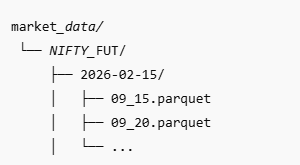

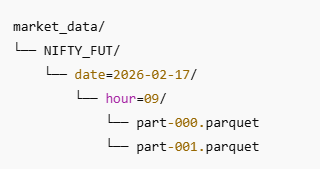

In [6]:
# Jupyter already has an event loop
task1 = asyncio.create_task(recorder.run())
# task2 = asyncio.create_task(recorder_best.run())

{'RequestCode': 23, 'InstrumentCount': 2, 'InstrumentList': [{'ExchangeSegment': 'NSE_EQ', 'SecurityId': '2885'}, {'ExchangeSegment': 'NSE_FNO', 'SecurityId': '51714'}]}
Appended 107160 rows → market_data\NIFTY_FUT\2026-03-16\13_36.parquet
Appended 108400 rows → market_data\NIFTY_FUT\2026-03-16\13_41.parquet
Appended 107280 rows → market_data\NIFTY_FUT\2026-03-16\13_46.parquet
Appended 107520 rows → market_data\NIFTY_FUT\2026-03-16\13_51.parquet
Appended 107680 rows → market_data\NIFTY_FUT\2026-03-16\13_56.parquet
Appended 107840 rows → market_data\NIFTY_FUT\2026-03-16\14_01.parquet
Appended 108400 rows → market_data\NIFTY_FUT\2026-03-16\14_06.parquet
Appended 106920 rows → market_data\NIFTY_FUT\2026-03-16\14_11.parquet
Appended 108440 rows → market_data\NIFTY_FUT\2026-03-16\14_16.parquet
Appended 107560 rows → market_data\NIFTY_FUT\2026-03-16\14_21.parquet
Appended 107440 rows → market_data\NIFTY_FUT\2026-03-16\14_26.parquet
Appended 107680 rows → market_data\NIFTY_FUT\2026-03-16\14_3

In [7]:
task1

<Task finished name='Task-40' coro=<MarketRecorder.run() done, defined at c:\GIT\market_game\incremental_indexed.py:159> exception=ConnectionClosedError(None, None, None)>

In [9]:
# task1.cancel()
# await task1